In [1]:
# Statistics

In [2]:
# Import relevant Python packages:
import xarray as xr
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

# Following pip installation as shown on the LT Toolbox github:
import lt_toolbox as ltt
import gsw.density as density

# Searching the OceanDataCatalog dataset

from OceanDataStore import OceanDataCatalog

catalog = OceanDataCatalog(catalog_name="noc-model-stac")

#catalog.available_collections

#Era 5 probs the best here

#Searching the ERA5 collection
#catalog.search(collection='noc-npd-era5')
#catalog.available_items

t1 = catalog.open_dataset(id= 'noc-npd-era5/npd-eorca1-era5v1/gn/T1y',
                          start_datetime='2000-01',
                          end_datetime='2010-12',
                          )

#t1


d1 = catalog.open_dataset(id= 'noc-npd-era5/npd-eorca1-era5v1/gn/domain/domain_cfg',
                          )

d1

  2026-04-21T10:46:29.727922Z  WARN aws_config::imds::region: failed to load region from IMDS, err: failed to load IMDS session token: dispatch failure: timeout: HTTP read timeout occurred after 1s: timed out (FailedToLoadToken(FailedToLoadToken { source: DispatchFailure(DispatchFailure { source: ConnectorError { kind: Timeout, source: HttpTimeoutError { kind: "HTTP read", duration: 1s }, connection: Unknown } }) }))
    at /root/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-config-1.8.12/src/imds/region.rs:66

  2026-04-21T10:46:36.126965Z  WARN aws_config::imds::region: failed to load region from IMDS, err: failed to load IMDS session token: dispatch failure: timeout: HTTP read timeout occurred after 1s: timed out (FailedToLoadToken(FailedToLoadToken { source: DispatchFailure(DispatchFailure { source: ConnectorError { kind: Timeout, source: HttpTimeoutError { kind: "HTTP read", duration: 1s }, connection: Unknown } }) }))
    at /root/.cargo/registry/src/index.crates.io-19

<xarray.Dataset> Size: 710MB
Dimensions:       (y: 331, x: 360, nav_lev: 75)
Coordinates:
  * y             (y) int64 3kB 0 1 2 3 4 5 6 7 ... 324 325 326 327 328 329 330
  * x             (x) int64 3kB 0 1 2 3 4 5 6 7 ... 353 354 355 356 357 358 359
  * nav_lev       (nav_lev) int64 600B 0 1 2 3 4 5 6 7 ... 68 69 70 71 72 73 74
Data variables: (12/49)
    e1t           (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    e1f           (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    e2f           (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    e2t           (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    e1u           (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    e2u           (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    ...            ...
    pacmsk        (y, x) float32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    tmask         (nav_lev, y, x) int8 9MB dask.array<chunksize=(75, 331, 360), meta=np.ndarray>
    vmask         (nav_lev, y, x) int8 9MB dask.array<chunksize=(75, 331, 360), meta=np.ndarray>
    socmsk        (y, x) float32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    wmask         (nav_lev, y, x) bool 9MB dask.array<chunksize=(75, 331, 360), meta=np.ndarray>
    tmaskutil     (y, x) int8 119kB dask.array<chunksize=(331, 360), meta=np.ndarray>
Attributes:
    CfgName:    UNKNOWN
    CfgIndex:   -999
    Iperio:     1
    Jperio:     0
    NFold:      1
    NFtype:     F
    VertCoord:  zps
    IsfCav:     0
    file_name:  mesh_mask.nc
    TimeStamp:  01/03/2025 22:19:49 -0000

In [3]:
# DONE!!! - Creating parquet files - Only needs to be done once
import polars as pl
import lt_toolbox as ltt
from pathlib import Path
import gc

# Model grid
lon_mdl = t1.nav_lon.values
lat_mdl = t1.nav_lat.values
depth_mdl = t1.deptht.values

# Output directory
output_dir = Path("/dssgfs01/scratch/emdh1n25/project_1m_RAPID_new/eORCA1/processed_traj")
output_dir.mkdir(parents=True, exist_ok=True)

for year in range(1990, 2000):
    for month in range(1, 13):

        mm = f"{month:02d}"
        key = f"{year}_{mm}"

        traj_filepath = Path(
            f"/dssgfs01/scratch/emdh1n25/project_1m_RAPID/"
            f"eORCA1/eORCA1_output/parquet_new/"
            f"ORCA1_NPD_{mm}_{year}_25_1m_run.parquet"
        )

        output_file = output_dir / f"{key}.parquet"

        if not traj_filepath.exists():
            print(f"Missing {key}, skipping")
            continue

        if output_file.exists():
            print(f"Skipping {key}, already processed")
            continue

        print(f"Processing {key}")

        try:
            # Load
            dataset = pl.read_parquet(traj_filepath)

            # Build trajectory object
            traj = ltt.TrajFrame(source=dataset, condense=True)

            # Convert time
            traj_geo = traj.use_datetime(
                start_date=f"{year}-01-01",
                unit="s"
            )

            # Save original x, y, z
            x_orig = traj_geo.data["x"]
            y_orig = traj_geo.data["y"]
            z_orig = traj_geo.data["z"]

            # Transform coordinates
            traj_geo_interp = traj_geo.transform_trajectory_coords(
                lon=lon_mdl,
                lat=lat_mdl,
                depth=depth_mdl
            )

            # Re-add original indices (overwrite if needed)
            traj_geo_interp.data = traj_geo_interp.data.with_columns([
                x_orig.alias("x"),
                y_orig.alias("y"),
                z_orig.alias("z"),
            ])

            # Reorder columns
            traj_geo_interp.data = traj_geo_interp.data.select(
                ["id", "x", "y", "z"]
                + [c for c in traj_geo_interp.data.columns if c not in ["id", "x", "y", "z"]]
            )

            # Save to disk
            traj_geo_interp.data.write_parquet(output_file)

        except Exception as e:
            print(f"Error processing {key}: {e}")
            continue

        # Cleanup
        del dataset, traj, traj_geo, traj_geo_interp
        gc.collect()

print("Done")

Processing 1990_01
Processing 1990_02
Processing 1990_03
Processing 1990_04
Processing 1990_05
Processing 1990_06
Processing 1990_07
Processing 1990_08
Processing 1990_09
Processing 1990_10
Processing 1990_11
Processing 1990_12
Processing 1991_01
Processing 1991_02
Processing 1991_03
Processing 1991_04
Processing 1991_05
Processing 1991_06
Processing 1991_07
Processing 1991_08
Processing 1991_09
Processing 1991_10
Processing 1991_11
Processing 1991_12
Processing 1992_01
Processing 1992_02
Processing 1992_03
Processing 1992_04
Processing 1992_05
Processing 1992_06
Processing 1992_07
Processing 1992_08
Processing 1992_09
Processing 1992_10
Processing 1992_11
Processing 1992_12
Processing 1993_01
Processing 1993_02
Processing 1993_03
Processing 1993_04
Processing 1993_05
Processing 1993_06
Processing 1993_07
Processing 1993_08
Processing 1993_09
Processing 1993_10
Processing 1993_11
Processing 1993_12
Processing 1994_01
Processing 1994_02
Processing 1994_03
Processing 1994_04
Processing 1

In [4]:
# Exploring one year
import polars as pl

df = pl.read_parquet("/dssgfs01/scratch/emdh1n25/project_1m_RAPID_new/eORCA1/processed_traj/1990_01.parquet")

df

id,x,y,z,lon,lat,depth,subvol,time,boxface,somxl010,hfds,thetao_con,so_abs,sowaflup,rsdo
i64,list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[datetime[μs]],list[i64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64]
1,"[206.16667, 206.15344, … 285.0425]","[229.0, 229.13592, … 312.0]","[0.83333, 1.0, … 30.72826]","[-80.33533, -80.348722, … 29.632842]","[26.913242, 27.032004, … 77.289247]","[1.380836, 1.555855, … 215.339196]","[1489.79048, 1489.79048, … 1489.79048]","[1990-01-01 00:00:00, 1990-01-02 05:32:52.164050, … 1997-11-03 04:53:01.466630]","[3, 5, … 3]","[29.82392, 39.56585, … 26.24995]","[-87.57001, -72.10684, … -132.75965]","[24.159, 23.54542, … 1.53092]","[36.2938, 36.37421, … 35.02072]","[0.00004, 0.00004, … -0.00024]","[141.52718, 96.75126, … 0.0]"
2,"[206.16667, 206.12081, … 258.25494]","[229.0, 229.44864, … 229.0]","[0.5, 1.0, … 29.02623]","[-80.33533, -80.381725, … -28.245023]","[26.913242, 27.305242, … 26.953199]","[1.030808, 1.555855, … 181.054593]","[1489.79048, 1489.79048, … 1489.79048]","[1990-01-01 00:00:00, 1990-01-05 18:20:03.145480, … 1998-10-20 02:31:46.025129]","[3, 5, … 4]","[29.82392, 40.42086, … 65.27448]","[-87.57001, -74.84408, … -162.25309]","[24.159, 23.58546, … 17.75948]","[36.2938, 36.36544, … 36.31825]","[0.00004, 0.00004, … 0.00006]","[141.52718, 98.93403, … 0.0072]"
3,"[206.16667, 206.06859, … 256.73521]","[229.0, 229.88598, … 229.0]","[0.16667, 1.0, … 31.06814]","[-80.33533, -80.434465, … -29.764917]","[26.913242, 27.687344, … 26.953166]","[0.680779, 1.555855, … 222.759462]","[1489.79048, 1489.79048, … 1489.79048]","[1990-01-01 00:00:00, 1990-01-13 23:30:03.439810, … 1998-01-04 15:08:25.454850]","[3, 5, … 4]","[29.82392, 42.59724, … 67.90148]","[-87.57001, -81.81161, … -30.04468]","[24.159, 23.68739, … 17.07798]","[36.2938, 36.34311, … 36.32486]","[0.00004, 0.00004, … 0.00002]","[141.52718, 104.49018, … 0.00414]"
4,"[206.5, 206.46031, … 268.0]","[229.0, 229.13592, … 258.26773]","[0.83333, 1.0, … 45.90515]","[-80.002015, -80.041867, … -18.094806]","[26.913545, 27.032299, … 50.040928]","[1.380836, 1.555855, … 1036.520404]","[1489.79048, 1489.79048, … 1489.79048]","[1990-01-01 00:00:00, 1990-01-02 05:32:52.164050, … 2014-06-05 03:54:23.383490]","[3, 5, … 1]","[29.82392, 39.56585, … 46.815]","[-87.57001, -72.10684, … -140.00973]","[24.159, 23.54542, … 6.0978]","[36.2938, 36.37421, … 35.18767]","[0.00004, 0.00004, … 0.00001]","[141.52718, 96.75126, … 0.0]"
5,"[206.5, 206.36242, … 220.0]","[229.0, 229.44864, … 286.10388]","[0.5, 1.0, … 26.5862]","[-80.002015, -80.140129, … -73.135525]","[26.913545, 27.305502, … 62.504873]","[1.030808, 1.555855, … 141.476318]","[1489.79048, 1489.79048, … 1489.79048]","[1990-01-01 00:00:00, 1990-01-05 18:20:03.145480, … 1997-11-20 21:31:44.473990]","[3, 5, … 2]","[29.82392, 40.42086, … 47.50942]","[-87.57001, -74.84408, … -31.52864]","[24.159, 23.58546, … 0.38728]","[36.2938, 36.36544, … 32.9972]","[0.00004, 0.00004, … 0.0002]","[141.52718, 98.93403, … 0.00004]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
28417,"[269.91667, 269.89553]","[229.0, 229.0]","[61.75, 61.8481]","[-16.58198, -16.603122]","[26.94962, 26.949632]","[3466.244385, 3484.766125]","[2414.93414, 2414.93414]","[1990-01-01 00:00:00, 1990-10-02 00:41:14.526510]","[3, 4]","[62.75772, 22.05507]","[-94.8344, 20.59849]","[2.31635, 2.33421]","[35.0962, 35.09781]","[0.00006, 0.00004]","[0.0, 0.0]"
28418,"[269.91667, 269.89553]","[229.0, 229.0]","[61.58333, 61.71516]","[-16.58198, -16.603122]","[26.94962, 26.949632]","[3434.776307, 3459.666429]","[2414.93414, 2414.93414]","[1990-01-01 00:00:00, 1990-10-02 00:41:14.526510]","[3, 4]","[62.75772, 22.05507]","[-94.8344, 20.59849]","[2.31635, 2.33421]","[35.0962, 35.09781]","[0.00006, 0.00004]","[0.0, 0.0]"
28419,"[269.91667, 269.89553]","[229.0, 229.0]","[61.41667, 61.58222]","[-16.58198, -16.603122]","[26.94962, 26.949632]","[3403.310118, 3434.566734]","[2414.93414, 2414.93414]","[1990-01-01 00:00:00, 1990-10-02 00:41:14.526510]","[3, 4]

[1/120] Processing 1990_01
[2/120] Processing 1990_02
[3/120] Processing 1990_03
[4/120] Processing 1990_04
[5/120] Processing 1990_05
[6/120] Processing 1990_06
[7/120] Processing 1990_07
[8/120] Processing 1990_08
[9/120] Processing 1990_09
[10/120] Processing 1990_10
[11/120] Processing 1990_11
[12/120] Processing 1990_12
[13/120] Processing 1991_01
[14/120] Processing 1991_02
[15/120] Processing 1991_03
[16/120] Processing 1991_04
[17/120] Processing 1991_05
[18/120] Processing 1991_06
[19/120] Processing 1991_07
[20/120] Processing 1991_08
[21/120] Processing 1991_09
[22/120] Processing 1991_10
[23/120] Processing 1991_11
[24/120] Processing 1991_12
[25/120] Processing 1992_01
[26/120] Processing 1992_02
[27/120] Processing 1992_03
[28/120] Processing 1992_04
[29/120] Processing 1992_05
[30/120] Processing 1992_06
[31/120] Processing 1992_07
[32/120] Processing 1992_08
[33/120] Processing 1992_09
[34/120] Processing 1992_10
[35/120] Processing 1992_11
[36/120] Processing 1992_12
[

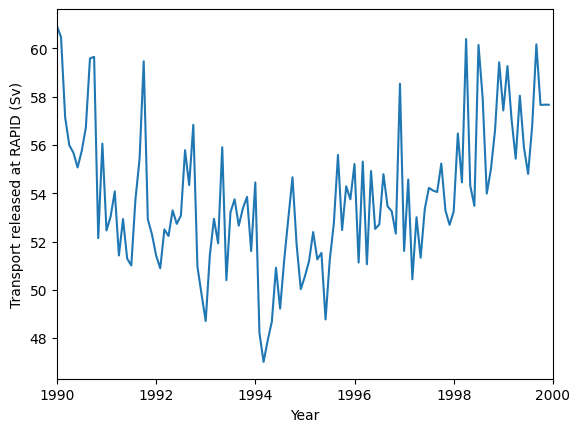

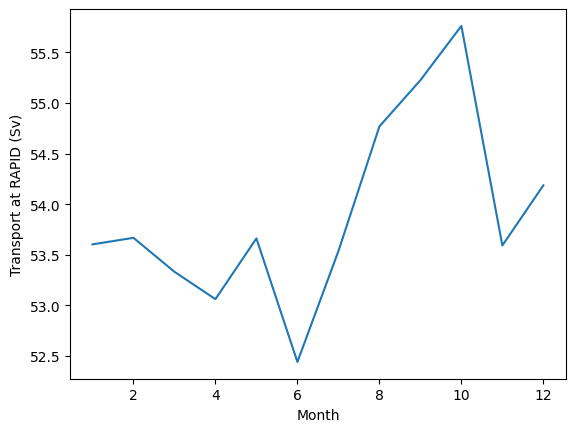

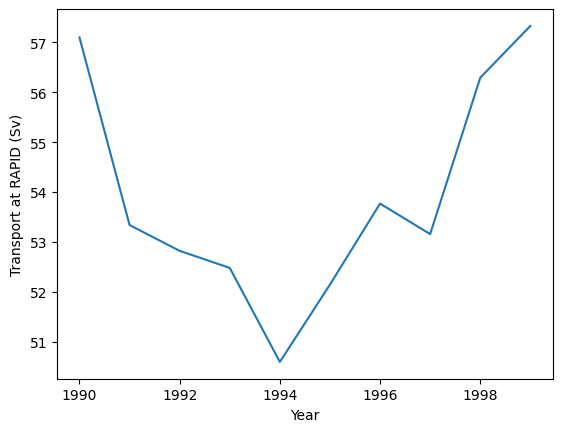

In [6]:
import polars as pl
from pathlib import Path
import matplotlib.pyplot as plt

data_dir = Path("/dssgfs01/scratch/emdh1n25/project_1m_RAPID_new/eORCA1/processed_traj")

results = {}

# -------------------------
# Progress setup
# -------------------------
total_files = 10 * 12  # 1990–1999 inclusive
processed = 0

# -------------------------
# 1. Read each monthly file
# -------------------------
for year in range(1990, 2000):
    for month in range(1, 13):

        processed += 1
        key = f"{year}_{month:02d}"
        file_path = data_dir / f"{key}.parquet"

        print(f"[{processed}/{total_files}] Processing {key}")

        if not file_path.exists():
            print(f"  Missing {key}")
            continue

        df = pl.read_parquet(file_path, columns=["subvol", "x"])

        results[key] = (
            df["subvol"]
            .list.first()
            .sum()
            / 1e6
        )

# -------------------------
# 2. Build dataframe
# -------------------------
results_df = pl.DataFrame({
    "year_month": list(results.keys()),
    "subvol_sum": list(results.values())
})

results_df = results_df.with_columns([
    pl.col("year_month")
      .str.extract(r"(\d{4})_(\d{2})", 1)
      .cast(pl.Int32)
      .alias("year"),

    pl.col("year_month")
      .str.extract(r"(\d{4})_(\d{2})", 2)
      .cast(pl.Int32)
      .alias("month"),
])

results_df = results_df.with_columns([
    (pl.col("year") + (pl.col("month") - 1) / 12).alias("time")
])

results_df_condensed_RAPID = results_df.select(["time", "subvol_sum"])

# -------------------------
# 3. Time series plot
# -------------------------
plt.figure()
plt.plot(
    results_df_condensed_RAPID["time"],
    results_df_condensed_RAPID["subvol_sum"]
)

plt.xlabel("Year")
plt.ylabel("Transport released at RAPID (Sv)")
#plt.ylim(46, 62)
plt.xlim(1990, 2000)
plt.show()

# -------------------------
# 4. Monthly climatology
# -------------------------
monthly_mean_RAPID = (
    results_df
    .group_by("month")
    .agg(pl.col("subvol_sum").mean().alias("subvol_mean"))
    .sort("month")
)

plt.figure()
plt.plot(
    monthly_mean_RAPID["month"],
    monthly_mean_RAPID["subvol_mean"]
)

plt.xlabel("Month")
plt.ylabel("Transport at RAPID (Sv)")
plt.show()

# -------------------------
# 5. Annual climatology
# -------------------------
annual_mean_RAPID = (
    results_df
    .group_by("year")
    .agg(pl.col("subvol_sum").mean().alias("subvol_mean"))
    .sort("year")
)

plt.figure()
plt.plot(
    annual_mean_RAPID["year"],
    annual_mean_RAPID["subvol_mean"]
)

plt.xlabel("Year")
plt.ylabel("Transport at RAPID (Sv)")
plt.show()

In [ ]:
import numpy as np
import polars as pl

# Store filtered DataFrames for all months
boundary_trajs = {}

# -------------------------
# Progress setup
# -------------------------
total_files = 10 * 12  # 1990–1999 inclusive
processed = 0

for year in range(1990, 2000):
    for month in range(1, 13):

        processed += 1
        key = f"{year}_{month:02d}"
        file_path = data_dir / f"{key}.parquet"

        print(f"[{processed}/{total_files}] Processing {key}")

        if not file_path.exists():
            print(f"  Missing {key}")
            continue
        
        # Get trajectory data for this month
        df = pl.read_parquet(file_path, columns=["subvol", "x", "y", "time"])

        # Optional: compute trajectory length
        df = df.with_columns(
            (pl.col("time").list.last() - pl.col("time").list.first()).alias("length_time")
        )

        xs_list = df["x"].to_list()
        ys_list = df["y"].to_list()
        
        # Function to check if a trajectory hits a condition
        def hit_condition(xs, ys, x_cond=None, y_cond=None):
            xs = np.array(xs[1:])  # skip first point
            ys = np.array(ys[1:])
            x_mask = np.ones_like(xs, dtype=bool) if x_cond is None else x_cond(xs)
            y_mask = np.ones_like(ys, dtype=bool) if y_cond is None else y_cond(ys)
            return np.any(x_mask & y_mask)
        
        # Define boundary conditions
        conditions = [
            lambda xs, ys: hit_condition(xs, ys, lambda x: (x>=205)&(x<=281), lambda y: y==229),  # RAPID
            lambda xs, ys: hit_condition(xs, ys, lambda x: x==281, lambda y: (y>=229)&(y<=245)),  # Med
            lambda xs, ys: hit_condition(xs, ys, lambda x: (x>=220)&(x<=225), lambda y: y==290) or
                           hit_condition(xs, ys, lambda x: x==220, lambda y: (y>=270)&(y<=290)),  # HS
            lambda xs, ys: hit_condition(xs, ys, lambda x: (x>=225)&(x<=250), lambda y: y==290),  # DS
            lambda xs, ys: hit_condition(xs, ys, lambda x: (x>=250)&(x<=278), lambda y: y==312),  # FS
            lambda xs, ys: hit_condition(xs, ys, lambda x: (x>=278)&(x<=296), lambda y: y==312) or
                           hit_condition(xs, ys, lambda x: x==296, lambda y: (y>=300)&(y<=312))  # BS
        ]

        # Boolean: does each trajectory hit any boundary?
        hit_any = [any(cond(xs, ys) for cond in conditions) for xs, ys in zip(xs_list, ys_list)]

        # Keep only trajectories that hit at least one boundary
        df_boundaries = df.filter(pl.Series(hit_any))
        
        # Store filtered DataFrame
        boundary_trajs[key] = df_boundaries

        print(f"Original: {len(df)}, Boundary hits: {len(df_boundaries)}")

[1/120] Processing 1990_01
Original: 28421, Boundary hits: 20757
[2/120] Processing 1990_02
Original: 28371, Boundary hits: 19809
[3/120] Processing 1990_03
Original: 27105, Boundary hits: 19049
[4/120] Processing 1990_04
Original: 26797, Boundary hits: 18800
[5/120] Processing 1990_05
Original: 26147, Boundary hits: 17438
[6/120] Processing 1990_06
Original: 26095, Boundary hits: 17371
[7/120] Processing 1990_07
Original: 26621, Boundary hits: 17734
[8/120] Processing 1990_08
Original: 26977, Boundary hits: 18155
[9/120] Processing 1990_09
Original: 28608, Boundary hits: 19204
[10/120] Processing 1990_10
Original: 28834, Boundary hits: 20080
[11/120] Processing 1990_11
Original: 24491, Boundary hits: 16578
[12/120] Processing 1990_12
Original: 26845, Boundary hits: 18723
[13/120] Processing 1991_01
Original: 24435, Boundary hits: 17111
[14/120] Processing 1991_02
Original: 24903, Boundary hits: 17490
[15/120] Processing 1991_03
Original: 25154, Boundary hits: 17357
[16/120] Processing

In [ ]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

# Initialize list to collect all lengths and removed trajectories
all_lengths = []

# Loop over all years and months
for year in range(1990, 2000):
    for month in range(1, 13):
        key = f"{year}_{month:02d}"
        df = boundary_trajs[key]

        # Compute length_time in years
        df = df.with_columns(
            ((pl.col("time").list.last() - pl.col("time").list.first()).dt.total_seconds() / (86400*365.25))
            .alias("length_years")
        )

        df_pd = df.to_pandas()
        length_years = df_pd['length_years'].to_numpy()

        # Compute number of removed trajectories
        n_removed = {len(df_boundaries)}

        # Add real lengths + "fake" removed 25-year trajectories
        all_lengths.extend(length_years)
        all_lengths.extend([25]*n_removed)

# Convert to numpy array
all_lengths = np.array(all_lengths)

# Compute scaling factor
#scale_factor = 0.30447404705082787 / 935421
# fraction remaining/ total trajectories

# Make histogram with scaled heights
plt.hist(all_lengths, bins=50, weights=np.ones_like(all_lengths),
         #*scale_factor,
         edgecolor='black')
plt.xlabel("Time in domain (years)")
plt.ylabel("Scaled count")
plt.title("Scaled histogram of trajectory times")
plt.show()

TypeError: can't multiply sequence by non-int of type 'set'

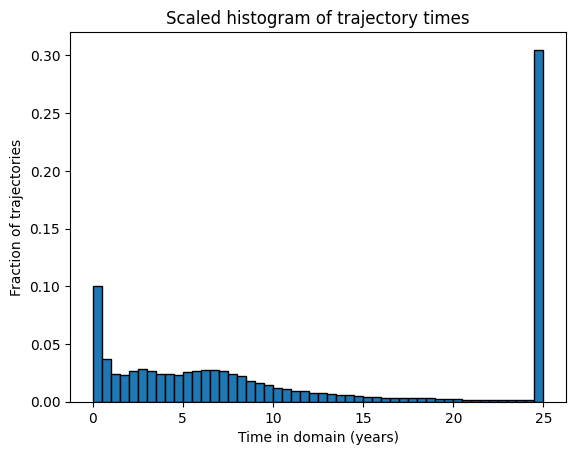

936102 0.3046957085551576
3072252


In [104]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

all_lengths = []

for year in range(1990, 2000):
    for month in range(1, 13):
        key = f"{year}_{month:02d}"

        file_path = data_dir / f"{key}.parquet"
        if not file_path.exists():
            continue

        df_full = pl.read_parquet(file_path, columns=["time"])
        df = boundary_trajs[key]

        df = df.with_columns(
            ((pl.col("time").list.last() - pl.col("time").list.first())
             .dt.total_seconds() / (86400 * 365.25))
            .alias("length_years")
        )

        length_years = df["length_years"].to_numpy()

        n_removed = len(df_full) - len(df)

        all_lengths.extend(length_years)
        all_lengths.extend([25] * n_removed)

# Convert to numpy
all_lengths = np.array(all_lengths)

# ✅ scaling
weights = np.ones_like(all_lengths) / len(all_lengths)

# Plot
plt.hist(all_lengths, bins=50,
         weights=weights,
         edgecolor='black')

plt.xlabel("Time in domain (years)")
plt.ylabel("Fraction of trajectories")
plt.title("Scaled histogram of trajectory times")
plt.show()


n_25 = np.sum(all_lengths == 25)
fraction_25 = n_25 / len(all_lengths)

print(n_25, fraction_25)
print(len(all_lengths))

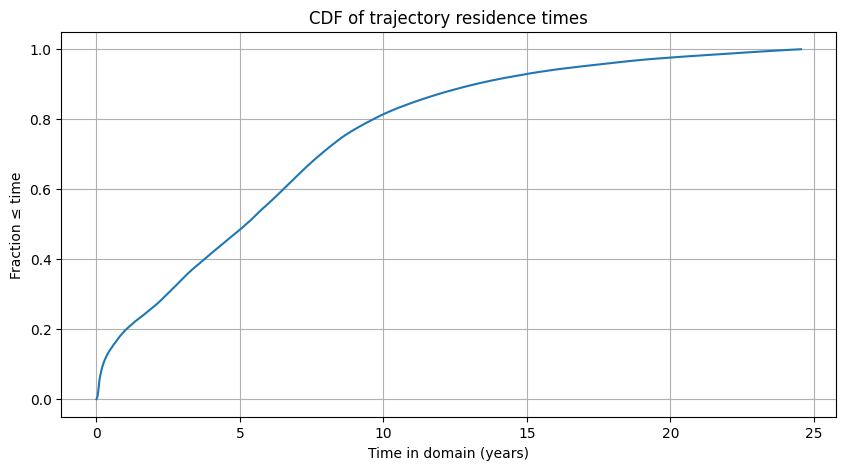

In [108]:
import numpy as np
import matplotlib.pyplot as plt

# remove artificial censoring values
real_lengths = all_lengths[all_lengths != 25]

# sort
x = np.sort(real_lengths)

# cumulative fraction
y = np.arange(1, len(x) + 1) / len(x)

plt.figure(figsize=(10, 5))
plt.plot(x, y)
plt.xlabel("Time in domain (years)")
plt.ylabel("Fraction ≤ time")
plt.title("CDF of trajectory residence times")
plt.grid()
plt.show()

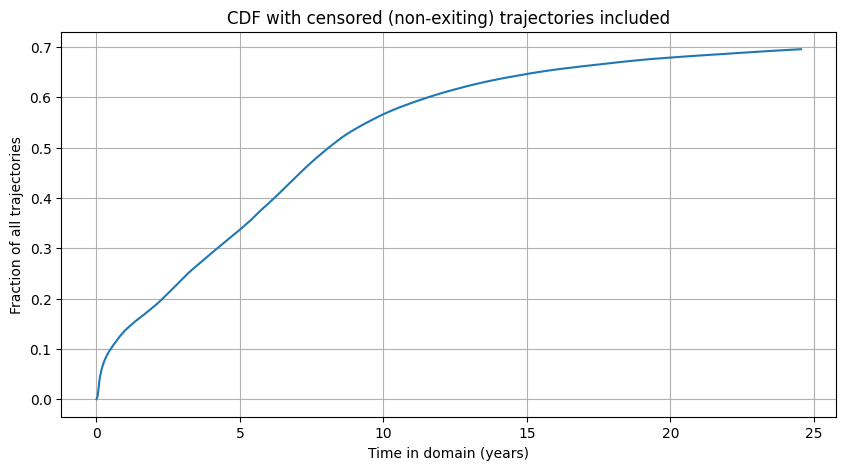

In [110]:
import numpy as np
import matplotlib.pyplot as plt

# separate real + censored
real = all_lengths[all_lengths != 25]
censored = all_lengths[all_lengths == 25]

n_total = len(all_lengths)

# sort only real values
x = np.sort(real)

# cumulative count of real exits
y = np.arange(1, len(x) + 1) / n_total

plt.figure(figsize=(10, 5))
plt.plot(x, y, label="Exited trajectories")

# final plateau at 1 - censored fraction
plateau = len(real) / n_total
#plt.hlines(plateau, x[0], x[-1], linestyles="dashed")

plt.xlabel("Time in domain (years)")
plt.ylabel("Fraction of all trajectories")
plt.title("CDF with censored (non-exiting) trajectories included")
plt.grid()
#plt.legend()
plt.show()

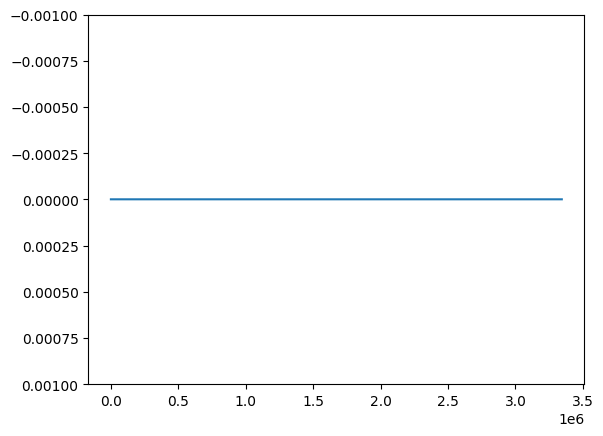

In [9]:
import matplotlib.pyplot as plt

df = pl.read_parquet("/dssgfs01/scratch/emdh1n25/project_1m_RAPID_new/eORCA1/processed_traj/1990_01.parquet")
# Your data
df_sowaflup = df['sowaflup'].explode().to_numpy()

# Plot
plt.plot(df_sowaflup)
plt.ylim(0.001, -0.001)


plt.show()

<xarray.DataArray 'sowaflup' (time_counter: 1, y: 331, x: 360)> Size: 477kB
[119160 values with dtype=float32]
Coordinates:
  * time_counter   (time_counter) datetime64[ns] 8B 2005-12-16T12:00:00
    time_centered  (time_counter) datetime64[ns] 8B ...
    nav_lat        (y, x) float32 477kB ...
    nav_lon        (y, x) float32 477kB ...
Dimensions without coordinates: y, x
Attributes:
    standard_name:       water_flux_out_of_sea_ice_and_sea_water
    long_name:           Net Upward Water Flux
    units:               kg/m2/s
    online_operation:    average
    interval_operation:  3600 s
    interval_write:      1 month
    cell_methods:        time: mean (interval: 3600 s)


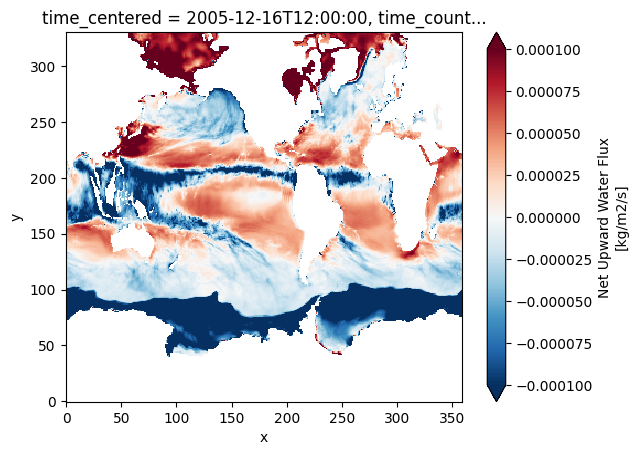

In [14]:
import xarray as xr

# Define your file path
example_nc = '/dssgfs01/scratch/npd/simulations/eORCA1_ERA5_v1/eORCA1_ERA5_1m_grid_T_200512-200512.nc'

ds = xr.open_dataset(example_nc)

# Preview the data structure
print(ds['sowaflup'])

da = ds['sowaflup'].squeeze()

# 2. Plotting
# Assuming 'da' is your squeezed DataArray
da.plot(
    cmap='RdBu_r', 
    vmin=-0.0001,  # Set the start of the color scale
    vmax=0.0001    # Set the end of the color scale
)

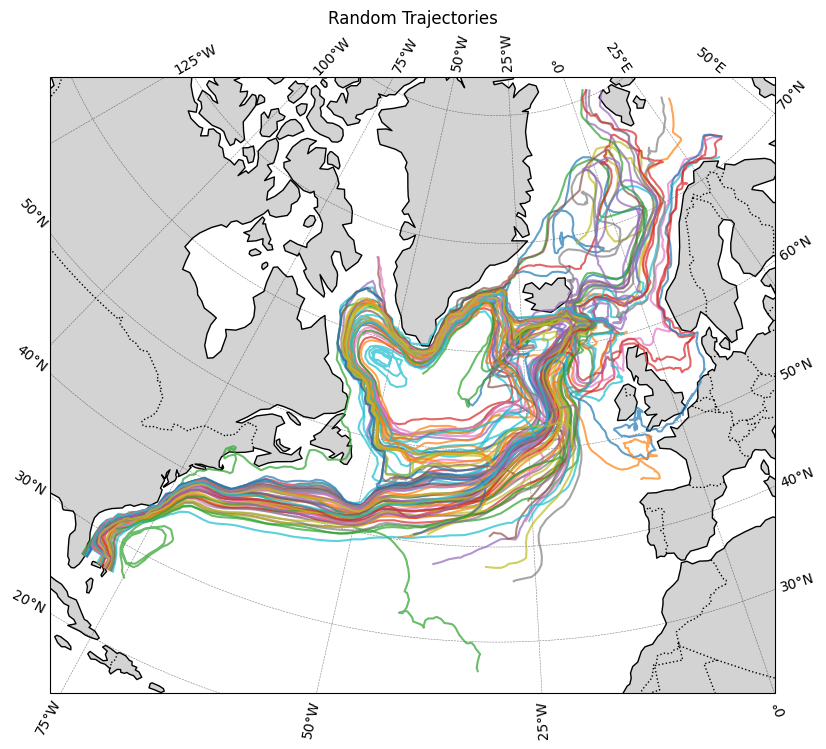

In [83]:
#Map setup for random trajectories
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

df = pl.read_parquet("/dssgfs01/scratch/emdh1n25/project_1m_RAPID_new/eORCA1/processed_traj/1990_01.parquet")

# Pick random trajectories
ids = df.select("id").unique().to_series().to_numpy()

# subset ids

ids = (df.filter(pl.col("lat").list.max() > 60).get_column("id").to_numpy())

ids_plot = np.random.choice(ids, size=50, replace=False)
#ids_plot = ids[::10][:5]

df_sub = df.filter(pl.col("id").is_in(ids_plot))

# Explode the lists to get individual points
df_exploded = df_sub.select(["id", "lon", "lat"]).explode(["lon", "lat"])

def setup_map(ax):
    ax.coastlines()
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False,
                      linewidth=0.4, alpha=0.5, linestyle='--', color='black')
    ax.set_extent([-80, 0, 20, 80])  # SPG region

# Create figure and map axes
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.LambertConformal(central_longitude=-30, central_latitude=50)})
setup_map(ax)

# Plot trajectories
for tid in ids_plot:
    dfi = df_exploded.filter(pl.col("id") == tid)
    ax.plot(
        dfi["lon"].to_numpy(),
        dfi["lat"].to_numpy(),
        alpha=0.7,
        transform=ccrs.PlateCarree()
    )

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Random Trajectories")
plt.show()

In [81]:
# Exploring one year
import polars as pl

df = pl.read_parquet("/dssgfs01/scratch/emdh1n25/project_1m_RAPID_new/eORCA1/processed_traj/1990_01.parquet")

df

id,x,y,z,lon,lat,depth,subvol,time,boxface,somxl010,hfds,thetao_con,so_abs,sowaflup,rsdo
i64,list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[datetime[μs]],list[i64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64]
1,"[206.16, 206.15, … 285.04]","[229.0, 229.13, … 312.0]","[0.83, 1.0, … 30.72]","[-80.341999, -80.352155, … 29.629256]","[26.913236, 27.026828, … 77.290087]","[1.377339, 1.555855, … 215.162835]","[1489.79, 1489.79, … 1489.79]","[1990-01-01 00:00:00, 1990-01-02 05:32:52.160, … 1997-11-03 04:53:01.470]","[3, 5, … 3]","[29.82, 39.57, … 26.25]","[-87.57, -72.11, … -132.76]","[24.16, 23.55, … 1.53]","[36.29, 36.37, … 35.02]","[0.0, 0.0, … -0.0]","[141.53, 96.75, … 0.0]"
2,"[206.16, 206.12, … 258.25]","[229.0, 229.44, … 229.0]","[0.5, 1.0, … 29.02]","[-80.341999, -80.382524, … -28.249963]","[26.913236, 27.297691, … 26.953199]","[1.030808, 1.555855, … 180.934727]","[1489.79, 1489.79, … 1489.79]","[1990-01-01 00:00:00, 1990-01-05 18:20:03.150, … 1998-10-20 02:31:46.029999]","[3, 5, … 4]","[29.82, 40.42, … 65.27]","[-87.57, -74.84, … -162.25]","[24.16, 23.59, … 17.76]","[36.29, 36.37, … 36.32]","[0.0, 0.0, … 0.0]","[141.53, 98.93, … 0.01]"
3,"[206.16, 206.06, … 256.73]","[229.0, 229.88, … 229.0]","[0.16, 1.0, … 31.06]","[-80.341999, -80.443047, … -29.770128]","[26.913236, 27.682108, … 26.953166]","[0.673775, 1.555855, … 222.566141]","[1489.79, 1489.79, … 1489.79]","[1990-01-01 00:00:00, 1990-01-13 23:30:03.440, … 1998-01-04 15:08:25.450]","[3, 5, … 4]","[29.82, 42.6, … 67.9]","[-87.57, -81.81, … -30.04]","[24.16, 23.69, … 17.08]","[36.29, 36.34, … 36.32]","[0.0, 0.0, … 0.0]","[141.53, 104.49, … 0.0]"
4,"[206.5, 206.46, … 268.0]","[229.0, 229.13, … 258.26]","[0.83, 1.0, … 45.9]","[-80.002015, -80.04217, … -18.095103]","[26.913545, 27.027125, … 50.035612]","[1.377339, 1.555855, … 1036.013611]","[1489.79, 1489.79, … 1489.79]","[1990-01-01 00:00:00, 1990-01-02 05:32:52.160, … 2014-06-05 03:54:23.380]","[3, 5, … 1]","[29.82, 39.57, … 46.82]","[-87.57, -72.11, … -140.01]","[24.16, 23.55, … 6.1]","[36.29, 36.37, … 35.19]","[0.0, 0.0, … 0.0]","[141.53, 96.75, … 0.0]"
5,"[206.5, 206.36, … 220.0]","[229.0, 229.44, … 286.1]","[0.5, 1.0, … 26.58]","[-80.002015, -80.142539, … -73.134042]","[26.913545, 27.297949, … 62.503289]","[1.030808, 1.555855, … 141.38747]","[1489.79, 1489.79, … 1489.79]","[1990-01-01 00:00:00, 1990-01-05 18:20:03.150, … 1997-11-20 21:31:44.470]","[3, 5, … 2]","[29.82, 40.42, … 47.51]","[-87.57, -74.84, … -31.53]","[24.16, 23.59, … 0.39]","[36.29, 36.37, … 33.0]","[0.0, 0.0, … 0.0]","[141.53, 98.93, … 0.0]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
28417,"[269.91, 269.89]","[229.0, 229.0]","[61.75, 61.84]","[-16.58865, -16.608653]","[26.949624, 26.949635]","[3466.244385, 3483.236807]","[2414.93, 2414.93]","[1990-01-01 00:00:00, 1990-10-02 00:41:14.530]","[3, 4]","[62.76, 22.06]","[-94.83, 20.6]","[2.32, 2.33]","[35.1, 35.1]","[0.0, 0.0]","[0.0, 0.0]"
28418,"[269.91, 269.89]","[229.0, 229.0]","[61.58, 61.71]","[-16.58865, -16.608653]","[26.949624, 26.949635]","[3434.147588, 3458.692197]","[2414.93, 2414.93]","[1990-01-01 00:00:00, 1990-10-02 00:41:14.530]","[3, 4]","[62.76, 22.06]","[-94.83, 20.6]","[2.32, 2.33]","[35.1, 35.1]","[0.0, 0.0]","[0.0, 0.0]"
28419,"[269.91, 269.89]","[229.0, 229.0]","[61.41, 61.58]","[-16.58865, -16.608653]","[26.949624, 26.949635]","[3402.050791, 3434.147588]","[2414.93, 2414.93]","[1990-01-01 00:00:00, 1990-10-02 00:41:14.530]","[3, 4]","[62.76, 22.06]","[-94.83, 20.6]","[2.32, 2.33]","[35.1, 35.1]","[0.0, 0.0]","[0.0, 0.0]"


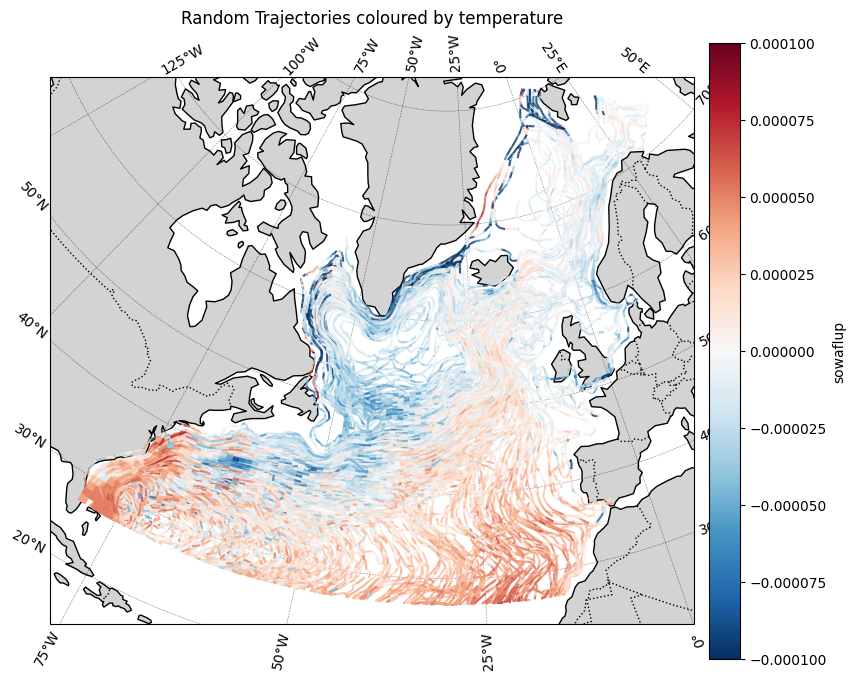

In [ ]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection
import cartopy.crs as ccrs
import cartopy.feature as cfeature

variable = "sowaflup"

df = pl.read_parquet("/dssgfs01/scratch/emdh1n25/project_1m_RAPID_new/eORCA1/processed_traj/1990_01.parquet")

ids = df.select("id").unique().to_series().to_numpy()
#ids = df.filter(pl.col("lat").list.max() > 60).get_column("id").to_numpy()

ids_plot = np.random.choice(ids, size=500, replace=False)

df_sub = df.filter(pl.col("id").is_in(ids_plot))

# Explode INCLUDING thetao_con
df_exploded = df_sub.select(
    ["id", "lon", "lat", variable]
).explode(["lon", "lat", variable])

# ----------------------------
# Map setup
# ----------------------------
def setup_map(ax):
    ax.coastlines()
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    gl = ax.gridlines(draw_labels=True, dms=True,
                      x_inline=False, y_inline=False,
                      linewidth=0.4, alpha=0.5,
                      linestyle='--', color='black')
    ax.set_extent([-80, 0, 20, 80])

fig, ax = plt.subplots(
    figsize=(10, 8),
    subplot_kw={
        'projection': ccrs.LambertConformal(
            central_longitude=-30,
            central_latitude=50
        )
    }
)
setup_map(ax)

# ----------------------------
# Colormap setup (GLOBAL scaling)
# ----------------------------
vmin = -0.0001 #df_exploded[variable].min()
vmax =  0.0001 #df_exploded[variable].max()

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.RdBu_r

# ----------------------------
# Plot trajectories with gradient colouring
# ----------------------------
for tid in ids_plot:
    dfi = df_exploded.filter(pl.col("id") == tid)

    lon = dfi["lon"].to_numpy()
    lat = dfi["lat"].to_numpy()
    val = dfi[variable].to_numpy()

    # Skip short tracks
    if len(lon) < 2:
        continue

    # Build line segments
    points = np.array([lon, lat]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    lc = LineCollection(
        segments,
        cmap=cmap,
        norm=norm,
        transform=ccrs.PlateCarree()
    )

    lc.set_array(val[:-1])  # match segment count
    lc.set_linewidth(1.5)
    lc.set_alpha(0.8)

    ax.add_collection(lc)

# ----------------------------
# Colorbar
# ----------------------------
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax, orientation='vertical', pad=0.02)
cbar.set_label(variable)

# ----------------------------
# Labels
# ----------------------------
plt.title("Random Trajectories coloured by freshwater forcing")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()